# INF2005 steganography: an end-to-end demonstration

This notebook follows one message from a sender to a receiver. The sender writes a
stego carrier and a public-key PEM file; the receiver then uses only those files.
The implementation supports strict RGB PNG and uncompressed PCM WAV carriers.

## Setup

The tracked `samples/Banana.png` file is the PNG cover. Every generated file is
written to a temporary directory and removed at the end.

In [1]:
import sys
import tempfile
import wave
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "stego" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from IPython.display import display
from PIL import Image

from stego import *

_demo_temp = tempfile.TemporaryDirectory(prefix="inf2005-demo-")
DEMO_DIR = Path(_demo_temp.name)
sample_png_path = REPO_ROOT / "samples" / "Banana.png"


def preview_image(path):
    with Image.open(path) as image:
        preview = image.copy()
    preview.thumbnail((320, 392))
    return preview

print(f"Temporary demonstration files: {DEMO_DIR}")
print(f"Sample cover: {sample_png_path}")

Temporary demonstration files: /tmp/inf2005-demo-6ws36asa
Sample cover: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png


## Act 1 — Sender: embed and publish

The sender loads the real RGB cover, signs a message, writes the stego PNG, and
publishes the public key as a PEM file. The preview below is downscaled for display
only; encoding always uses the original 1280 × 1568 image.

Public key PEM: /tmp/inf2005-demo-6ws36asa/banana-public-key.pem
Public-key fingerprint: SHA256:dtaDOSCcYJNjubdc+ssBTBGcq3Y0vMdJrLYocUtZ2fg
Stego PNG: /tmp/inf2005-demo-6ws36asa/banana-stego.png
PNG layout: {'payload_length': 168, 'footprint': 1192, 'lsb_count': 3}
Cover (left) and stego image (right), downscaled for display:


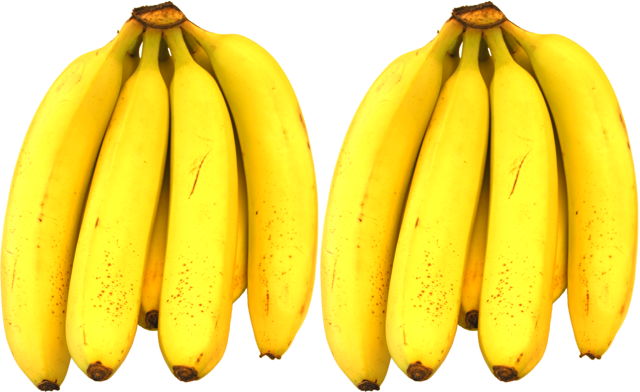

In [2]:
private_key, public_key = generate_rsa_keypair()
public_key_path = DEMO_DIR / "banana-public-key.pem"
stego_png_path = DEMO_DIR / "banana-stego.png"
start_unit = 4096
lsb_count = 3
image_message = b"INF2005 end-to-end image demonstration"
image_metadata = b"kind=png;flow=sender-receiver"

png_layout, png_payload = encode_png(
    sample_png_path,
    stego_png_path,
    private_key,
    start_unit=start_unit,
    lsb_count=lsb_count,
    user_payload=image_message,
    metadata=image_metadata,
)
save_rsa_public_key_pem(public_key, public_key_path)

cover_preview = preview_image(sample_png_path)
stego_preview = preview_image(stego_png_path)
png_preview = Image.new("RGB", (cover_preview.width + stego_preview.width, max(cover_preview.height, stego_preview.height)))
png_preview.paste(cover_preview, (0, 0))
png_preview.paste(stego_preview, (cover_preview.width, 0))
print("Public key PEM:", public_key_path)
print("Public-key fingerprint:", display_rsa_public_key_fingerprint(public_key))
print("Stego PNG:", stego_png_path)
print("PNG layout:", {"payload_length": png_layout.payload_length, "footprint": png_layout.footprint, "lsb_count": png_layout.lsb_count})
print("Cover (left) and stego image (right), downscaled for display:")
display(png_preview)

# Sender-only state is deliberately discarded before the receiver acts.
del private_key
# The receiver will not inherit the signing key, layout, cover pixels, or embedding settings.
del public_key, png_layout, png_payload, cover_preview, stego_preview, png_preview
del start_unit, lsb_count, image_message, image_metadata

## Act 2 — Receiver: verify from files only

The receiver is given only the stego file path and the public-key PEM path. The
decoder scans the carrier for the start marker and recovers the embedding start
location and LSB count; the receiver is not told either value. This is the key
property demonstrated by this flow.

In [3]:
receiver_public_key = load_rsa_public_key_pem(public_key_path)
png_result = verify_png(stego_png_path, receiver_public_key)
print("PNG verdict:", png_result.verdict)
print("Media ID:", png_result.payload.media_id)
print("Timestamp:", png_result.payload.timestamp)
print("Recovered message:", png_result.payload.user_payload.decode("utf-8"))

PNG verdict: Authentic
Media ID: IMG-234f5c2c5f7475dbe8fd9bfd92cde1ac
Timestamp: 1789207686
Recovered message: INF2005 end-to-end image demonstration


## Act 3 — Failure cases

These checks use the same receiver inputs but change the carrier or the supplied
public key. They show the protocol's distinct verdicts.

In [4]:
altered_png_path = DEMO_DIR / "banana-altered.png"
altered_image = load_png_from_path(stego_png_path)
altered_carrier = rgb_array_to_carrier(altered_image)
altered_carrier[-1] ^= np.uint8(1)
save_rgb_png_to_path(carrier_to_rgb_array(altered_carrier, altered_image.shape), altered_png_path)
print("Altered PNG verdict:", verify_png(altered_png_path, receiver_public_key).verdict)

actionless_private_key, wrong_public_key = generate_rsa_keypair()
del actionless_private_key
print("Wrong-key PNG verdict:", verify_png(stego_png_path, wrong_public_key).verdict)
print("Untouched cover verdict:", verify_png(sample_png_path, receiver_public_key).verdict)
del wrong_public_key, altered_image, altered_carrier

Altered PNG verdict: Tampered
Wrong-key PNG verdict: Signature Invalid


Untouched cover verdict: Payload Missing


## Act 4 — WAV: the same story, condensed

For audio, the sender creates a short mono 8-bit PCM sine tone in the temporary
directory, embeds a message, and publishes its public key. The receiver then
verifies from the two file paths; one altered frame demonstrates tamper detection.

In [5]:
wav_cover_path = DEMO_DIR / "tone-cover.wav"
wav_stego_path = DEMO_DIR / "tone-stego.wav"
wav_public_key_path = DEMO_DIR / "tone-public-key.pem"
wav_altered_path = DEMO_DIR / "tone-altered.wav"
wav_samples = (128 + 90 * np.sin(2 * np.pi * 440 * np.arange(32000) / 8000)).astype(np.uint8).tobytes()
with wave.open(str(wav_cover_path), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(1)
    wav_file.setframerate(8000)
    wav_file.writeframes(wav_samples)

wav_private_key, wav_public_key = generate_rsa_keypair()
wav_start_unit = 61
wav_lsb_count = 5
wav_layout, wav_payload = encode_wav(
    wav_cover_path,
    wav_stego_path,
    wav_private_key,
    start_unit=wav_start_unit,
    lsb_count=wav_lsb_count,
    user_payload=b"INF2005 end-to-end audio demonstration",
    metadata=b"kind=wav;flow=sender-receiver",
)
save_rsa_public_key_pem(wav_public_key, wav_public_key_path)

# Keep the WAV receiver step independent of the sender's key and layout too.
del wav_private_key, wav_public_key, wav_layout, wav_payload, wav_samples
del wav_start_unit, wav_lsb_count
wav_receiver_key = load_rsa_public_key_pem(wav_public_key_path)
wav_result = verify_wav(wav_stego_path, wav_receiver_key)
print("WAV verdict:", wav_result.verdict)
print("WAV recovered message:", wav_result.payload.user_payload.decode("utf-8"))

wav_data = load_pcm_wav_from_path(wav_stego_path)
wav_carrier = wav_frame_bytes_to_carrier(wav_data.frame_bytes)
wav_carrier[-1] ^= np.uint8(1)
save_pcm_wav_to_path(wav_data_with_carrier(wav_data, wav_carrier), wav_altered_path)
print("Altered WAV verdict:", verify_wav(wav_altered_path, wav_receiver_key).verdict)
del wav_data, wav_carrier

WAV verdict: Authentic
WAV recovered message: INF2005 end-to-end audio demonstration
Altered WAV verdict: Tampered


## Appendix — Analysis: compare k=1 and k=8

This is a visual and layout comparison, not part of the sender-to-receiver flow.
Both encodings use the full-resolution cover; only the previews are downscaled.

{'k': 1, 'capacity_bits': 6021120, 'packet_bits': 3376, 'footprint': 3376, 'changed_values': 1791, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
{'k': 8, 'capacity_bits': 48168960, 'packet_bits': 3376, 'footprint': 422, 'changed_values': 421, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
Cover (left), k=1 (middle), and k=8 (right), downscaled for display:


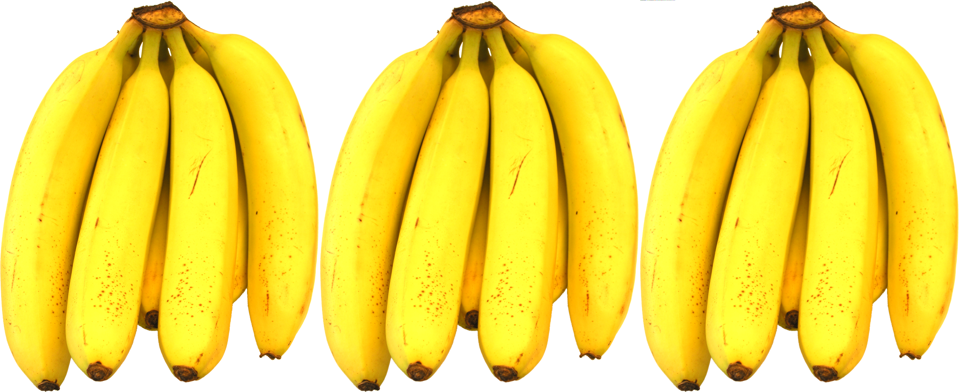

In [6]:
analysis_private_key, analysis_public_key = generate_rsa_keypair()
analysis_rows = []
analysis_previews = []
analysis_cover_array = load_png_from_path(sample_png_path)
analysis_cover_image = Image.fromarray(analysis_cover_array, mode="RGB")
for analysis_k in (1, 8):
    analysis_output = DEMO_DIR / f"banana-analysis-k{analysis_k}.png"
    analysis_layout, _ = encode_png(
        sample_png_path,
        analysis_output,
        analysis_private_key,
        start_unit=0,
        lsb_count=analysis_k,
        user_payload=b"same analysis payload",
        metadata=b"analysis=k comparison",
    )
    analysis_result = verify_png(analysis_output, analysis_public_key)
    analysis_image = np.asarray(Image.open(analysis_output), dtype=np.uint8)
    changed_values = int(np.count_nonzero(analysis_image != analysis_cover_array))
    preserved = preserved_bit_count(analysis_layout.total_units, analysis_layout.footprint, analysis_layout.lsb_count)
    packet_bits = (PACKET_HEADER_SIZE + analysis_layout.payload_length + RSA_SIGNATURE_SIZE) * 8
    analysis_rows.append({
        "k": analysis_k,
        "capacity_bits": analysis_layout.total_units * analysis_k,
        "packet_bits": packet_bits,
        "footprint": analysis_layout.footprint,
        "changed_values": changed_values,
        "preserved_ratio": f"{preserved / (analysis_layout.total_units * 8):.2%}",
        "verdict": analysis_result.verdict,
    })
    analysis_preview = Image.fromarray(analysis_image, mode="RGB")
    analysis_preview.thumbnail((320, 392))
    analysis_previews.append(analysis_preview)
for row in analysis_rows:
    print(row)
analysis_comparison = Image.new("RGB", (analysis_cover_image.width // 4 * 3, analysis_cover_image.height // 4))
analysis_cover_preview = analysis_cover_image.resize((analysis_cover_image.width // 4, analysis_cover_image.height // 4))
analysis_comparison.paste(analysis_cover_preview, (0, 0))
for index, analysis_preview in enumerate(analysis_previews, start=1):
    analysis_comparison.paste(analysis_preview, (index * analysis_cover_preview.width, 0))
print("Cover (left), k=1 (middle), and k=8 (right), downscaled for display:")
display(analysis_comparison)
del analysis_private_key, analysis_public_key, analysis_cover_array, analysis_cover_image, analysis_rows, analysis_previews, analysis_comparison, analysis_cover_preview

## Finish

All generated artifacts are temporary demonstration outputs.

In [7]:
_demo_temp.cleanup()
print("Temporary demonstration files removed.")

Temporary demonstration files removed.
